# Tách ảnh màu thành các thành phần R, G, B

Notebook này lấy mẫu ảnh theo lưới Bayer **RGGB** để tạo ba ảnh thưa: ảnh R chỉ có các pixel R, ảnh G chỉ có các pixel G, và ảnh B chỉ có các pixel B; mọi vị trí còn lại là đen. Ghép ba ảnh này lại sẽ cho Bayer mosaic. Không có nội suy (demosaicing) hay khôi phục ảnh.

In [23]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Đổi tên tệp nếu bạn muốn dùng ảnh khác.
image_path = Path('kodim19.png')

if not image_path.exists():
    raise FileNotFoundError(f'Không tìm thấy ảnh: {image_path.resolve()}')

rgb = np.asarray(Image.open(image_path).convert('RGB'))
print(f'Kích thước ảnh: {rgb.shape[1]} x {rgb.shape[0]} pixel')


Kích thước ảnh: 512 x 768 pixel


In [24]:
# Lấy ba giá trị màu gốc; các giá trị này sẽ được lấy mẫu theo lưới Bayer ở cell sau.
red = rgb[..., 0]
green = rgb[..., 1]
blue = rgb[..., 2]

print('Mỗi kênh có kích thước:', red.shape)


Mỗi kênh có kích thước: (768, 512)


In [25]:
# Bayer CFA theo ô 2x2 kiểu RGGB:
# R G
# G B
h, w = rgb.shape[:2]
red_mask = np.zeros((h, w), dtype=bool)
green_mask = np.zeros((h, w), dtype=bool)
blue_mask = np.zeros((h, w), dtype=bool)

red_mask[0::2, 0::2] = True
green_mask[0::2, 1::2] = True
green_mask[1::2, 0::2] = True
blue_mask[1::2, 1::2] = True

# Mỗi ma trận dưới đây chỉ chứa các mẫu được cảm biến giữ lại.
red_samples = np.where(red_mask, red, 0)
green_samples = np.where(green_mask, green, 0)
blue_samples = np.where(blue_mask, blue, 0)

# Ba ảnh RGB thưa: mỗi ảnh chỉ có pixel của MỘT màu tại đúng vị trí Bayer.
red_bayer_image = np.zeros_like(rgb)
green_bayer_image = np.zeros_like(rgb)
blue_bayer_image = np.zeros_like(rgb)
red_bayer_image[..., 0] = red_samples
green_bayer_image[..., 1] = green_samples
blue_bayer_image[..., 2] = blue_samples

# Ghép ba ảnh thưa: tại mỗi pixel chỉ tồn tại duy nhất R, G hoặc B.
bayer_mosaic_rgb = red_bayer_image + green_bayer_image + blue_bayer_image


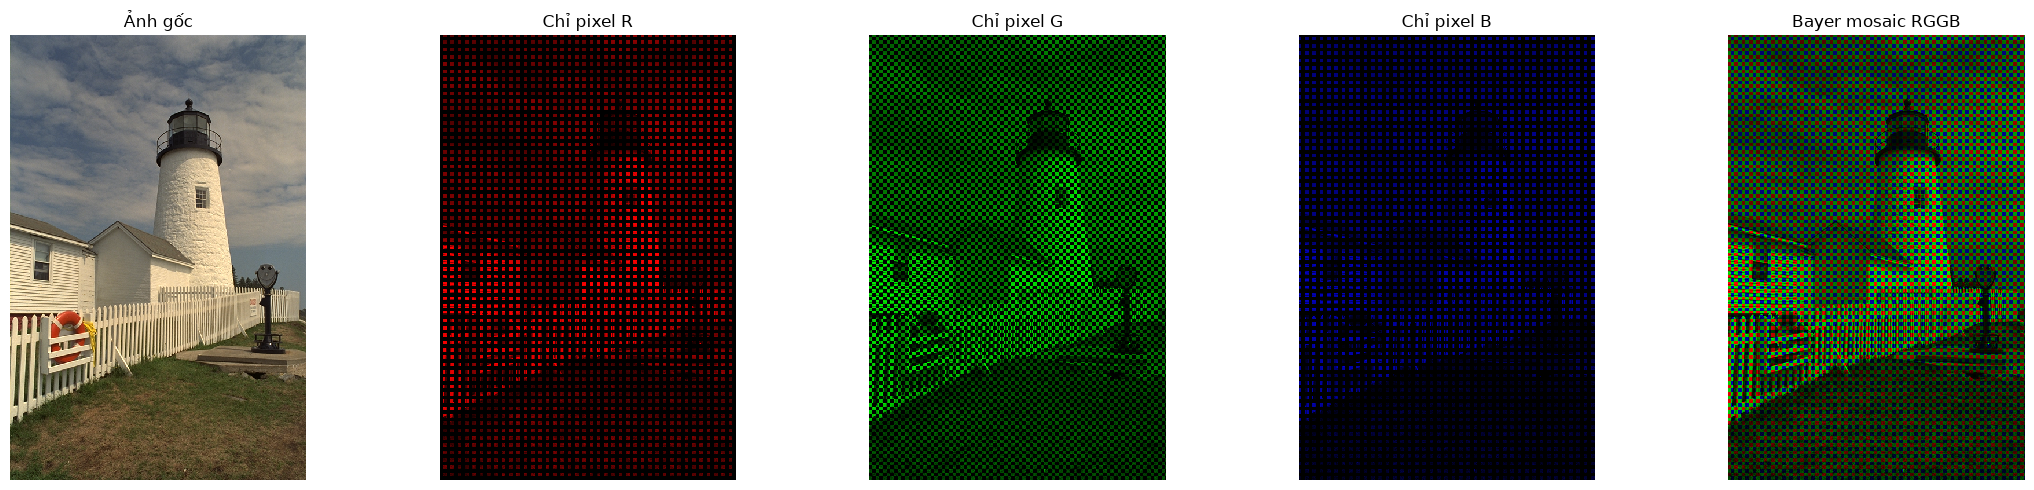

Kích thước Bayer mosaic: (768, 512, 3)


In [26]:
# Bốn ảnh dưới đây là kết quả cần xem. Dùng toàn ảnh để thấy bố cục;
# phóng to bằng cách đặt crop_size (ví dụ 200) nếu muốn thấy rõ ô RGGB.
crop_size = None  # Ví dụ: 200. Để None sẽ hiển thị toàn ảnh.
sl = np.s_[:, :] if crop_size is None else np.s_[:crop_size, :crop_size]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, image, title in zip(
    axes,
    [rgb[sl], red_bayer_image[sl], green_bayer_image[sl], blue_bayer_image[sl], bayer_mosaic_rgb[sl]],
    ['Ảnh gốc', 'Chỉ pixel R', 'Chỉ pixel G', 'Chỉ pixel B', 'Bayer mosaic RGGB'],
):
    # nearest: mỗi phần tử ma trận là đúng một pixel Bayer, không làm mờ/pha trộn pixel.
    ax.imshow(image, interpolation='nearest')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

print('Kích thước Bayer mosaic:', bayer_mosaic_rgb.shape)


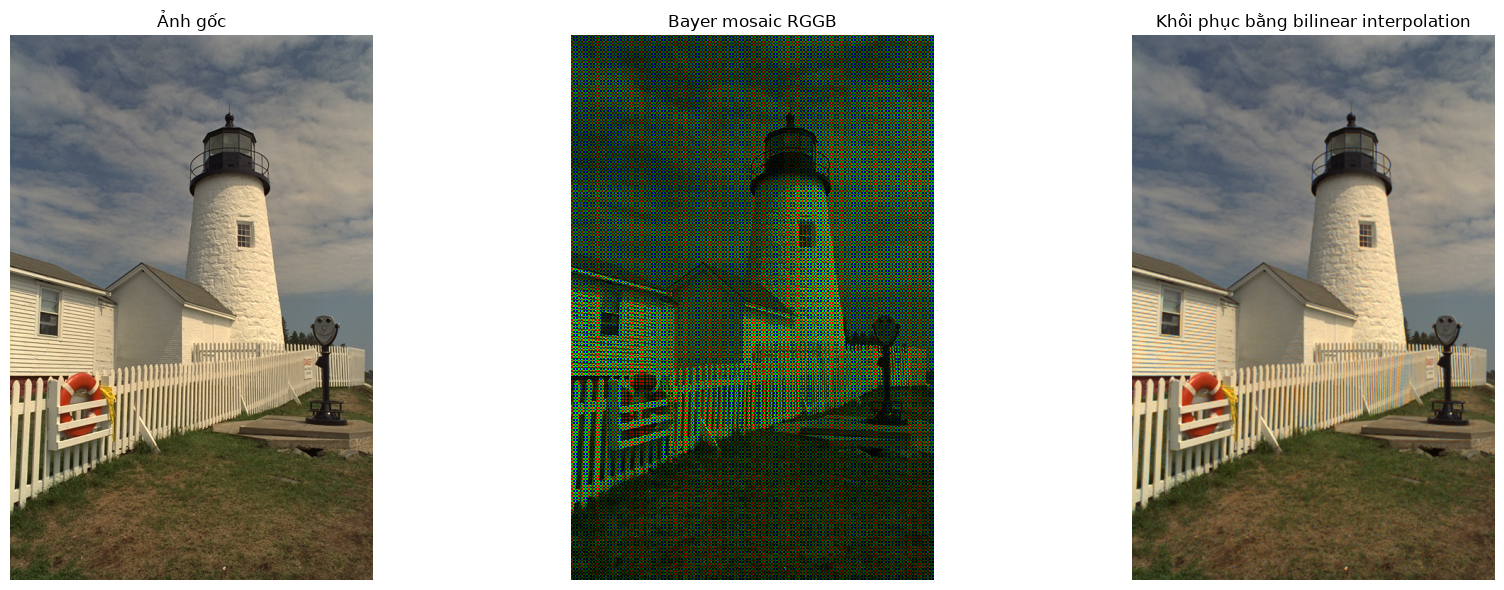

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# bayer_mosaic_rgb có dạng (H, W, 3):
# mỗi pixel chỉ có đúng một thành phần R, G hoặc B khác 0.
mosaic = bayer_mosaic_rgb.astype(np.float32)

# Tách các mặt phẳng mẫu Bayer thưa
r_sparse = mosaic[..., 0]
g_sparse = mosaic[..., 1]
b_sparse = mosaic[..., 2]

# Kernel bilinear theo công thức trong tài liệu
kernel_rb = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32) / 4

kernel_g = np.array([
    [0, 1, 0],
    [1, 4, 1],
    [0, 1, 0]
], dtype=np.float32) / 4


def convolve_3x3(image, kernel):
    """Tích chập 2D 3x3, không cần dùng OpenCV/SciPy."""
    padded = np.pad(image, pad_width=1, mode="reflect")
    result = np.zeros_like(image, dtype=np.float32)

    for i in range(3):
        for j in range(3):
            result += kernel[i, j] * padded[
                i:i + image.shape[0],
                j:j + image.shape[1]
            ]

    return result


# Nội suy các giá trị màu đang thiếu
r_reconstructed = convolve_3x3(r_sparse, kernel_rb)
g_reconstructed = convolve_3x3(g_sparse, kernel_g)
b_reconstructed = convolve_3x3(b_sparse, kernel_rb)

# Ghép ba kênh đã nội suy để tạo ảnh RGB khôi phục
reconstructed_rgb = np.stack(
    [r_reconstructed, g_reconstructed, b_reconstructed],
    axis=-1
)

reconstructed_rgb = np.clip(reconstructed_rgb, 0, 255).astype(np.uint8)

# So sánh ảnh gốc, Bayer mosaic và ảnh sau nội suy
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(rgb)
axes[0].set_title("Ảnh gốc")

axes[1].imshow(bayer_mosaic_rgb, interpolation="nearest")
axes[1].set_title("Bayer mosaic RGGB")

axes[2].imshow(reconstructed_rgb)
axes[2].set_title("Khôi phục bằng bilinear interpolation")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [28]:
def calculate_psnr(reference, test, max_pixel_value=255.0):
    """
    Tính PSNR giữa ảnh tham chiếu và ảnh cần đánh giá.

    reference: ảnh gốc/tham chiếu
    test: ảnh khôi phục
    """
    reference = reference.astype(np.float64)
    test = test.astype(np.float64)

    if reference.shape != test.shape:
        raise ValueError(
            f"Hai ảnh phải cùng kích thước. "
            f"reference={reference.shape}, test={test.shape}"
        )

    mse = np.mean((reference - test) ** 2)

    if mse == 0:
        return float("inf")

    return 10 * np.log10((max_pixel_value ** 2) / mse)


# Chọn đúng ảnh gốc cùng kích thước với ảnh đã nội suy
reference_image = rgb_input if "rgb_input" in globals() else rgb

psnr_value = calculate_psnr(reference_image, reconstructed_rgb)

print(f"PSNR tổng (RGB): {psnr_value:.2f} dB")

PSNR tổng (RGB): 28.16 dB


In [29]:
def calculate_mse(reference, test):
    """
    Tính Mean Squared Error (MSE) giữa ảnh tham chiếu và ảnh cần đánh giá.
    """
    reference = reference.astype(np.float64)
    test = test.astype(np.float64)

    if reference.shape != test.shape:
        raise ValueError(
            f"Hai ảnh phải cùng kích thước. "
            f"reference={reference.shape}, test={test.shape}"
        )

    return np.mean((reference - test) ** 2)
reference_image = rgb_input if "rgb_input" in globals() else rgb

mse_value = calculate_mse(reference_image, reconstructed_rgb)
psnr_value = calculate_psnr(reference_image, reconstructed_rgb)

print(f"MSE tổng (RGB): {mse_value:.4f}")
print(f"PSNR tổng (RGB): {psnr_value:.2f} dB")

MSE tổng (RGB): 99.2697
PSNR tổng (RGB): 28.16 dB
